# Notebook 01 -- Exploratory Data Analysis

Initial exploration of NCAA March Madness data for both **Men's (M)** and **Women's (W)** tournaments.  
Goals: understand dataset shapes, scoring patterns, home-court effects, seed dynamics, conference strength, and ranking system coverage.

## 1. Setup

In [1]:
%matplotlib inline

import sys
import os

# Ensure src/ is importable
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import (
    load_teams,
    load_seasons,
    load_regular_season_results,
    load_tourney_results,
    load_seeds,
    load_massey_ordinals,
    load_conferences,
    load_team_conferences,
    load_coaches,
    load_all_results,
    parse_seed,
)

# Plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# Pandas display
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", "{:.2f}".format)

print("Setup complete.")

Setup complete.


## 2. Data Loading and Overview

In [2]:
# Load core datasets for both genders
m_teams = load_teams("M")
w_teams = load_teams("W")

m_reg = load_regular_season_results("M")
w_reg = load_regular_season_results("W")

m_tourney = load_tourney_results("M")
w_tourney = load_tourney_results("W")

m_seeds = load_seeds("M")
w_seeds = load_seeds("W")

conferences = load_conferences()
m_team_conf = load_team_conferences("M")
w_team_conf = load_team_conferences("W")

m_seasons = load_seasons("M")
w_seasons = load_seasons("W")

print("All datasets loaded.")

All datasets loaded.


In [3]:
# Quick overview: shapes, season ranges, null counts
datasets = {
    "M Teams": m_teams,
    "W Teams": w_teams,
    "M Regular Season": m_reg,
    "W Regular Season": w_reg,
    "M Tournament": m_tourney,
    "W Tournament": w_tourney,
    "M Seeds": m_seeds,
    "W Seeds": w_seeds,
    "Conferences": conferences,
}

summary_rows = []
for name, df in datasets.items():
    row = {
        "Dataset": name,
        "Rows": df.shape[0],
        "Cols": df.shape[1],
        "Nulls": int(df.isnull().sum().sum()),
    }
    if "Season" in df.columns:
        row["Season Min"] = int(df["Season"].min())
        row["Season Max"] = int(df["Season"].max())
    else:
        row["Season Min"] = "-"
        row["Season Max"] = "-"
    summary_rows.append(row)

pd.DataFrame(summary_rows).set_index("Dataset")

,Rows,Cols,Nulls,Season Min,Season Max
Dataset,,,,,
M Teams,381,4,0,-,-
W Teams,379,2,0,-,-
M Regular Season,196823,8,0,1985,2026
W Regular Season,140825,8,0,1998,2026
M Tournament,2585,8,0,1985,2025
W Tournament,1717,8,0,1998,2025
M Seeds,2626,3,0,1985,2025
W Seeds,1744,3,0,1998,2025
Conferences,51,2,0,-,-


In [4]:
# Sample rows from men's regular season
print("Men's Regular Season -- first 3 rows:")
display(m_reg.head(3))
print("\nDtypes:")
print(m_reg.dtypes)

Men's Regular Season -- first 3 rows:


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,20,1228,81,1328,64,N,0
1,1985,25,1106,77,1354,70,H,0
2,1985,25,1112,63,1223,56,H,0



Dtypes:
Season     int64
DayNum     int64
WTeamID    int64
WScore     int64
LTeamID    int64
LScore     int64
WLoc         str
NumOT      int64
dtype: object


In [5]:
# Descriptive stats for scoring columns
print("Men's Regular Season -- Score Statistics:")
display(m_reg[["WScore", "LScore", "NumOT"]].describe())

print("\nWomen's Regular Season -- Score Statistics:")
display(w_reg[["WScore", "LScore", "NumOT"]].describe())

Men's Regular Season -- Score Statistics:


,WScore,LScore,NumOT
count,196823.00,196823.00,196823.00
mean,76.96,64.86,0.05
std,11.83,11.20,0.26
min,34.00,20.00,0.00
25%,69.00,57.00,0.00
50%,76.00,64.00,0.00
75%,84.00,72.00,0.00
max,186.00,150.00,6.00



Women's Regular Season -- Score Statistics:


,WScore,LScore,NumOT
count,140825.00,140825.00,140825.00
mean,71.97,57.52,0.04
std,11.40,10.79,0.23
min,30.00,11.00,0.00
25%,64.00,50.00,0.00
50%,71.00,57.00,0.00
75%,79.00,64.00,0.00
max,140.00,130.00,5.00


## 3. Score Distributions

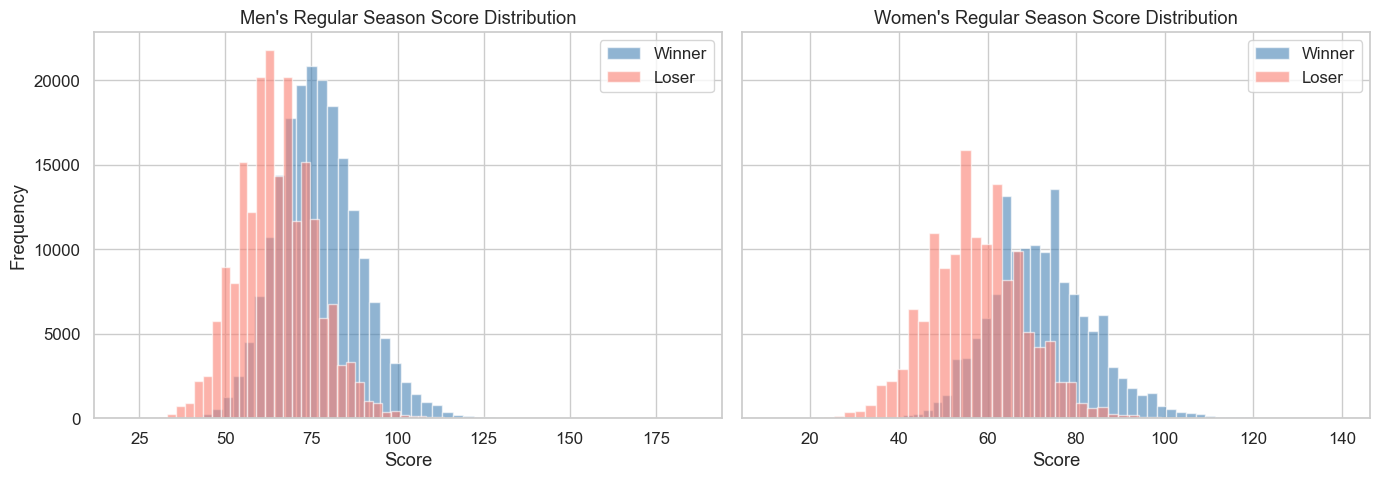

Men's -- Mean winning score: 77.0, Mean losing score: 64.9, Mean margin: 12.1
Women's -- Mean winning score: 72.0, Mean losing score: 57.5, Mean margin: 14.5


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (label, df) in zip(axes, [("Men's", m_reg), ("Women's", w_reg)]):
    ax.hist(df["WScore"], bins=50, alpha=0.6, label="Winner", color="steelblue")
    ax.hist(df["LScore"], bins=50, alpha=0.6, label="Loser", color="salmon")
    ax.set_title(f"{label} Regular Season Score Distribution")
    ax.set_xlabel("Score")
    ax.legend()

axes[0].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

# Summary
for label, df in [("Men's", m_reg), ("Women's", w_reg)]:
    margin = df["WScore"] - df["LScore"]
    print(f"{label} -- Mean winning score: {df['WScore'].mean():.1f}, "
          f"Mean losing score: {df['LScore'].mean():.1f}, "
          f"Mean margin: {margin.mean():.1f}")

## 4. Scoring Trends Over Time

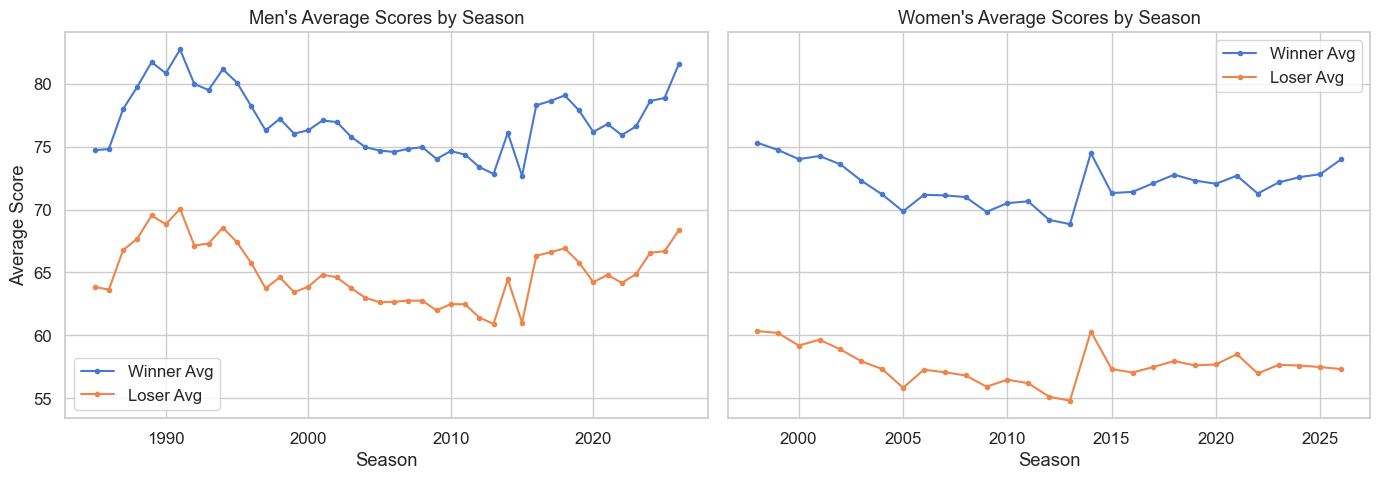

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (label, df) in zip(axes, [("Men's", m_reg), ("Women's", w_reg)]):
    season_avg = df.groupby("Season")[["WScore", "LScore"]].mean()
    ax.plot(season_avg.index, season_avg["WScore"], marker=".", label="Winner Avg", linewidth=1.5)
    ax.plot(season_avg.index, season_avg["LScore"], marker=".", label="Loser Avg", linewidth=1.5)
    ax.set_title(f"{label} Average Scores by Season")
    ax.set_xlabel("Season")
    ax.legend()

axes[0].set_ylabel("Average Score")
plt.tight_layout()
plt.show()

## 5. Home Court Advantage

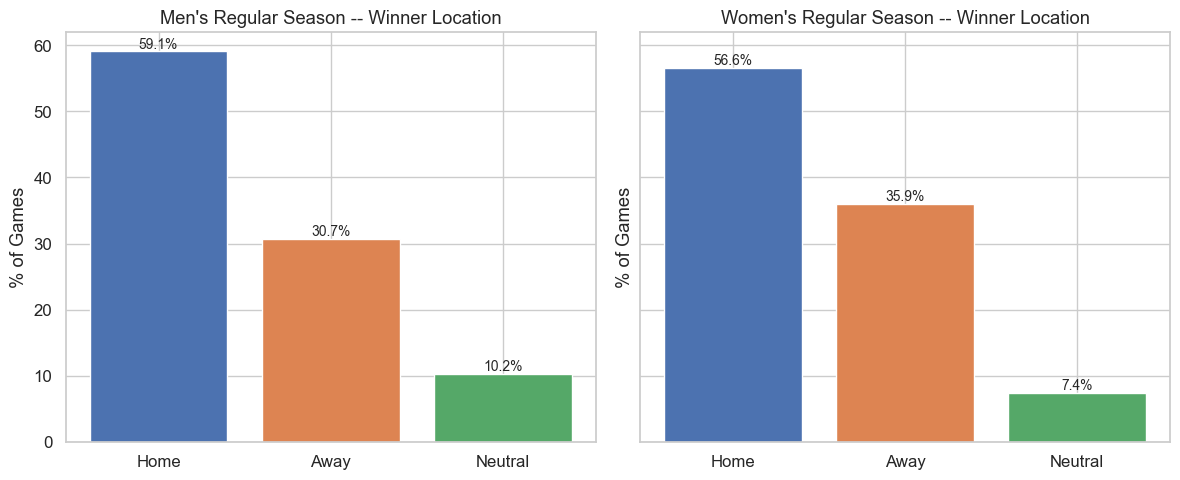

Interpretation: A large share of wins occur at the Home venue, confirming 
home-court advantage. The 'Away' column shows the winner was playing away 
(i.e., the away team won), which is much less common.


In [8]:
def compute_wloc_stats(df):
    """Return game counts and percentages by WLoc."""
    counts = df["WLoc"].value_counts()
    pcts = df["WLoc"].value_counts(normalize=True) * 100
    return pd.DataFrame({"Games": counts, "Pct": pcts})


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
loc_labels = {"H": "Home", "A": "Away", "N": "Neutral"}

for ax, (label, df) in zip(axes, [("Men's", m_reg), ("Women's", w_reg)]):
    stats = compute_wloc_stats(df).reindex(["H", "A", "N"])
    bars = ax.bar([loc_labels[x] for x in stats.index], stats["Pct"],
                  color=["#4c72b0", "#dd8452", "#55a868"])
    ax.set_title(f"{label} Regular Season -- Winner Location")
    ax.set_ylabel("% of Games")
    # Annotate bars
    for bar, pct in zip(bars, stats["Pct"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{pct:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

print("Interpretation: A large share of wins occur at the Home venue, confirming ")
print("home-court advantage. The 'Away' column shows the winner was playing away ")
print("(i.e., the away team won), which is much less common.")

## 6. Overtime Analysis

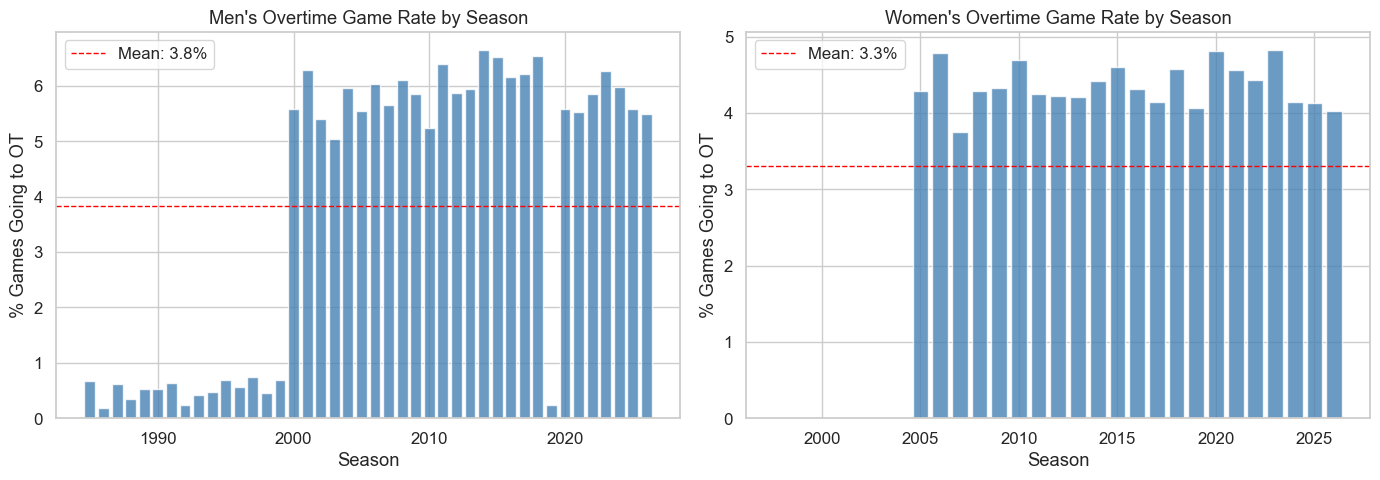

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, df) in zip(axes, [("Men's", m_reg), ("Women's", w_reg)]):
    ot_by_season = df.groupby("Season").apply(lambda g: (g["NumOT"] > 0).mean() * 100)
    ax.bar(ot_by_season.index, ot_by_season.values, color="steelblue", alpha=0.8)
    ax.set_title(f"{label} Overtime Game Rate by Season")
    ax.set_xlabel("Season")
    ax.set_ylabel("% Games Going to OT")
    ax.axhline(ot_by_season.mean(), color="red", linestyle="--", linewidth=1,
               label=f"Mean: {ot_by_season.mean():.1f}%")
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Tournament Seed Analysis

In [10]:
# Parse seed numbers and merge with tournament results
def add_seed_numbers(tourney_df, seeds_df):
    """Merge seed numbers onto winning and losing teams."""
    seeds = seeds_df.copy()
    seeds["SeedNum"] = seeds["Seed"].apply(lambda s: parse_seed(s)["seed_number"])

    df = tourney_df.merge(
        seeds[["Season", "TeamID", "SeedNum"]],
        left_on=["Season", "WTeamID"],
        right_on=["Season", "TeamID"],
        how="left",
    ).rename(columns={"SeedNum": "WSeed"}).drop(columns="TeamID")

    df = df.merge(
        seeds[["Season", "TeamID", "SeedNum"]],
        left_on=["Season", "LTeamID"],
        right_on=["Season", "TeamID"],
        how="left",
    ).rename(columns={"SeedNum": "LSeed"}).drop(columns="TeamID")

    return df


m_tourney_seeds = add_seed_numbers(m_tourney, m_seeds)
w_tourney_seeds = add_seed_numbers(w_tourney, w_seeds)

print(f"Men's tourney with seeds: {m_tourney_seeds.shape}")
m_tourney_seeds.head(3)

Men's tourney with seeds: (2585, 10)


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WSeed,LSeed
0,1985,136,1116,63,1234,54,N,0,9,8
1,1985,136,1120,59,1345,58,N,0,11,6
2,1985,136,1207,68,1250,43,N,0,1,16


### 7a. Wins by Seed Number

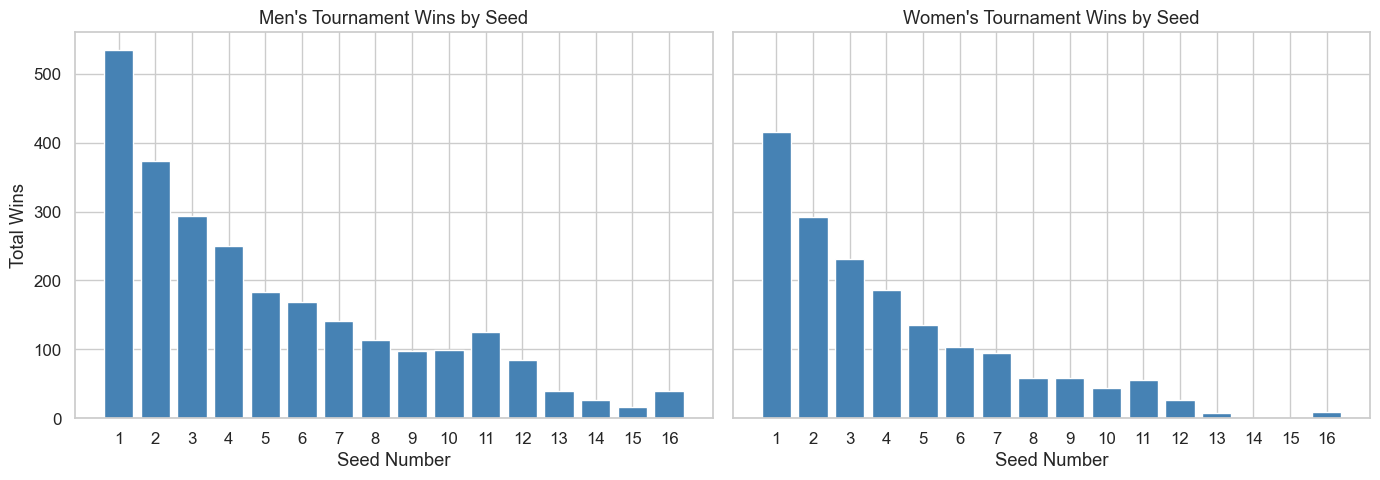

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (label, df) in zip(axes, [("Men's", m_tourney_seeds), ("Women's", w_tourney_seeds)]):
    win_counts = df["WSeed"].value_counts().sort_index()
    ax.bar(win_counts.index, win_counts.values, color="steelblue")
    ax.set_title(f"{label} Tournament Wins by Seed")
    ax.set_xlabel("Seed Number")
    ax.set_xticks(range(1, 17))

axes[0].set_ylabel("Total Wins")
plt.tight_layout()
plt.show()

### 7b. Upset Rates by Seed Difference

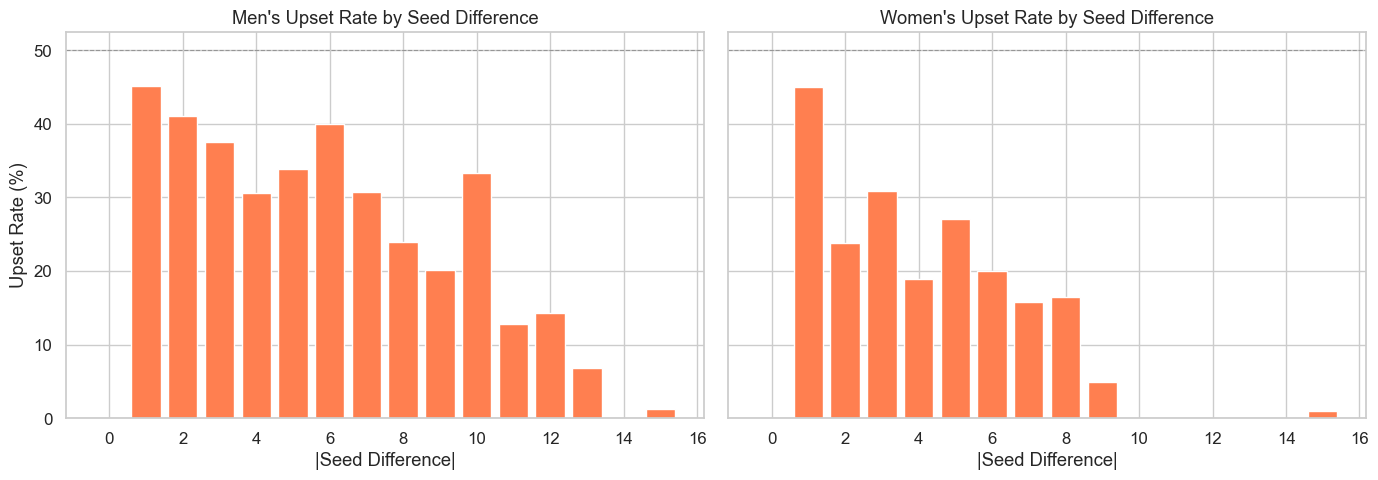

Note: Upset rate naturally decreases as seed difference grows,
since larger gaps indicate stronger favorites.


In [12]:
def upset_analysis(df):
    """Compute upset rate by absolute seed difference.
    An 'upset' = the higher-numbered (worse) seed wins."""
    tmp = df.dropna(subset=["WSeed", "LSeed"]).copy()
    tmp["SeedDiff"] = (tmp["LSeed"] - tmp["WSeed"]).astype(int)  # positive = favorite won
    tmp["Upset"] = tmp["WSeed"] > tmp["LSeed"]  # winner had a worse seed
    tmp["AbsDiff"] = tmp["SeedDiff"].abs()

    grouped = tmp.groupby("AbsDiff").agg(
        Games=("Upset", "count"),
        Upsets=("Upset", "sum"),
    )
    grouped["UpsetRate"] = grouped["Upsets"] / grouped["Games"] * 100
    return grouped


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (label, df) in zip(axes, [("Men's", m_tourney_seeds), ("Women's", w_tourney_seeds)]):
    upset_df = upset_analysis(df)
    # Filter to seed differences with enough games
    upset_df = upset_df[upset_df["Games"] >= 5]
    ax.bar(upset_df.index, upset_df["UpsetRate"], color="coral")
    ax.set_title(f"{label} Upset Rate by Seed Difference")
    ax.set_xlabel("|Seed Difference|")
    ax.axhline(50, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

axes[0].set_ylabel("Upset Rate (%)")
plt.tight_layout()
plt.show()

print("Note: Upset rate naturally decreases as seed difference grows,")
print("since larger gaps indicate stronger favorites.")

### 7c. Championship Game Winners by Seed

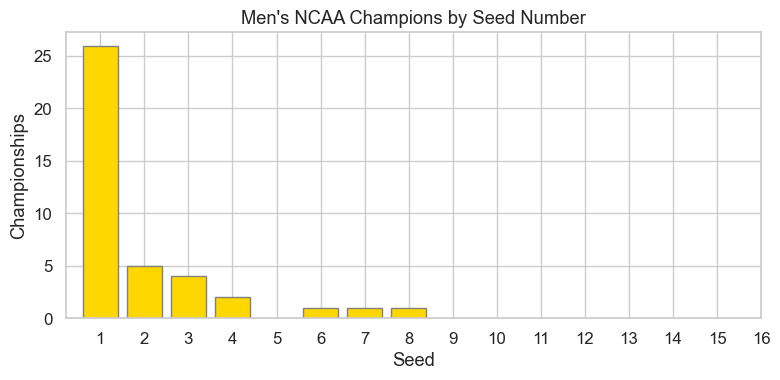


Recent Men's Champions:


,Season,TeamName,ChampSeed,WScore,LScore
0,2015,Duke,1,68,63
1,2016,Villanova,2,77,74
2,2017,North Carolina,1,71,65
3,2018,Villanova,1,79,62
4,2019,Virginia,1,85,77
5,2021,Baylor,1,86,70
6,2022,Kansas,1,72,69
7,2023,Connecticut,4,76,59
8,2024,Connecticut,1,75,60
9,2025,Florida,1,65,63


In [13]:
def get_champions(tourney_df, seeds_df, teams_df):
    """Identify the championship game winner each season.
    The championship game is the one with the highest DayNum per season."""
    champ_games = tourney_df.loc[
        tourney_df.groupby("Season")["DayNum"].idxmax()
    ].copy()

    seeds = seeds_df.copy()
    seeds["SeedNum"] = seeds["Seed"].apply(lambda s: parse_seed(s)["seed_number"])

    champ_games = champ_games.merge(
        seeds[["Season", "TeamID", "SeedNum"]],
        left_on=["Season", "WTeamID"],
        right_on=["Season", "TeamID"],
        how="left",
    ).rename(columns={"SeedNum": "ChampSeed"}).drop(columns="TeamID")

    champ_games = champ_games.merge(
        teams_df[["TeamID", "TeamName"]],
        left_on="WTeamID",
        right_on="TeamID",
        how="left",
    ).drop(columns="TeamID")

    return champ_games[["Season", "TeamName", "ChampSeed", "WScore", "LScore"]]


m_champs = get_champions(m_tourney, m_seeds, m_teams)

fig, ax = plt.subplots(figsize=(8, 4))
champ_seed_counts = m_champs["ChampSeed"].value_counts().sort_index()
ax.bar(champ_seed_counts.index, champ_seed_counts.values, color="gold", edgecolor="gray")
ax.set_title("Men's NCAA Champions by Seed Number")
ax.set_xlabel("Seed")
ax.set_ylabel("Championships")
ax.set_xticks(range(1, 17))
plt.tight_layout()
plt.show()

# Show last 10 champions
print("\nRecent Men's Champions:")
display(m_champs.tail(10).reset_index(drop=True))

## 8. Conference Strength

Which conferences produce the most tournament wins per season?

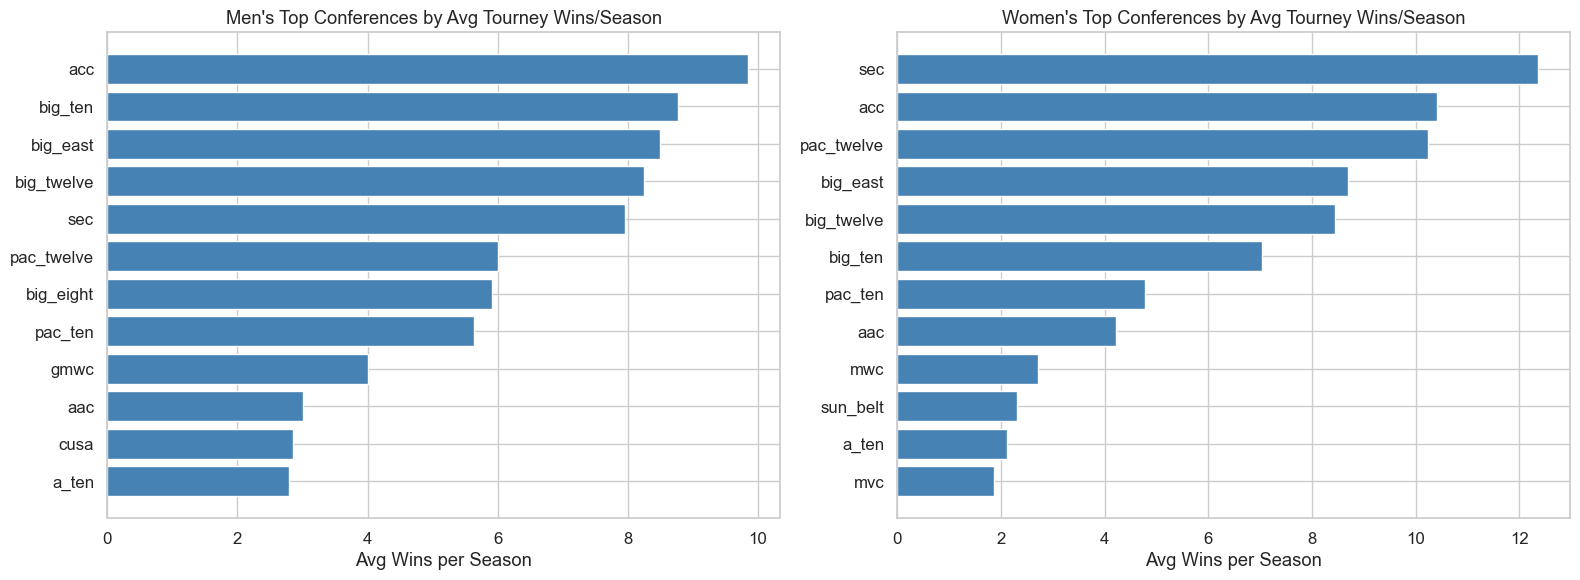

In [14]:
def conference_tourney_wins(tourney_df, team_conf_df, conf_df, top_n=15):
    """Average tournament wins per season for each conference."""
    # Map winning team to its conference that season
    merged = tourney_df.merge(
        team_conf_df,
        left_on=["Season", "WTeamID"],
        right_on=["Season", "TeamID"],
        how="left",
    )

    wins_per_conf_season = (
        merged.groupby(["Season", "ConfAbbrev"])
        .size()
        .reset_index(name="Wins")
    )

    avg_wins = (
        wins_per_conf_season.groupby("ConfAbbrev")["Wins"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )

    # Join conference full names
    avg_wins = avg_wins.merge(conf_df, on="ConfAbbrev", how="left")
    return avg_wins


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (label, t_df, tc_df) in zip(
    axes,
    [("Men's", m_tourney, m_team_conf), ("Women's", w_tourney, w_team_conf)],
):
    top_conf = conference_tourney_wins(t_df, tc_df, conferences, top_n=12)
    ax.barh(top_conf["ConfAbbrev"], top_conf["Wins"], color="steelblue")
    ax.set_title(f"{label} Top Conferences by Avg Tourney Wins/Season")
    ax.set_xlabel("Avg Wins per Season")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Men's vs Women's Comparison

In [15]:
def compute_key_stats(reg_df, tourney_df, label):
    """Compute summary statistics for one gender."""
    margin = reg_df["WScore"] - reg_df["LScore"]
    return {
        "Gender": label,
        "Reg Season Games": len(reg_df),
        "Tournament Games": len(tourney_df),
        "Season Range": f"{reg_df['Season'].min()}-{reg_df['Season'].max()}",
        "Avg Winner Score": reg_df["WScore"].mean(),
        "Avg Loser Score": reg_df["LScore"].mean(),
        "Avg Margin": margin.mean(),
        "OT Rate (%)": (reg_df["NumOT"] > 0).mean() * 100,
        "Max Score": reg_df["WScore"].max(),
    }


comparison = pd.DataFrame([
    compute_key_stats(m_reg, m_tourney, "Men's"),
    compute_key_stats(w_reg, w_tourney, "Women's"),
]).set_index("Gender")

display(comparison.T)

Gender,Men's,Women's
Reg Season Games,196823,140825
Tournament Games,2585,1717
Season Range,1985-2026,1998-2026
Avg Winner Score,76.96,71.97
Avg Loser Score,64.86,57.52
Avg Margin,12.10,14.46
OT Rate (%),4.10,3.41
Max Score,186,140


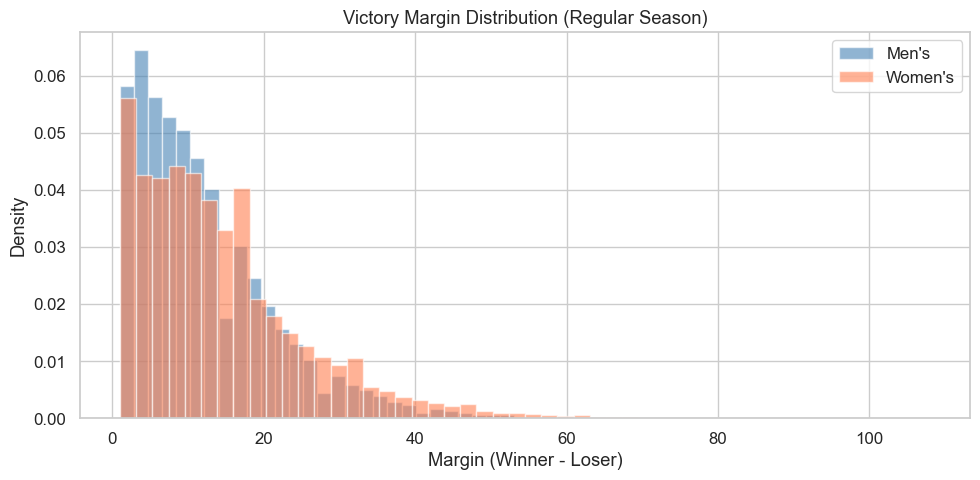

In [16]:
# Side-by-side margin distributions
fig, ax = plt.subplots(figsize=(10, 5))
m_margin = m_reg["WScore"] - m_reg["LScore"]
w_margin = w_reg["WScore"] - w_reg["LScore"]

ax.hist(m_margin, bins=50, alpha=0.6, label="Men's", color="steelblue", density=True)
ax.hist(w_margin, bins=50, alpha=0.6, label="Women's", color="coral", density=True)
ax.set_title("Victory Margin Distribution (Regular Season)")
ax.set_xlabel("Margin (Winner - Loser)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Massey Ordinals Preview (Men's Only)

The Massey Ordinals contain weekly rankings from many different computer ranking systems. This section previews coverage and agreement among top systems.

In [17]:
# Load Massey Ordinals (large file, may take a moment)
massey = load_massey_ordinals()
print(f"Shape: {massey.shape}")
massey.head(3)

Shape: (5761702, 5)


,Season,RankingDayNum,SystemName,TeamID,OrdinalRank
0,2003,35,SEL,1102,159
1,2003,35,SEL,1103,229
2,2003,35,SEL,1104,12


Total unique ranking systems: 196


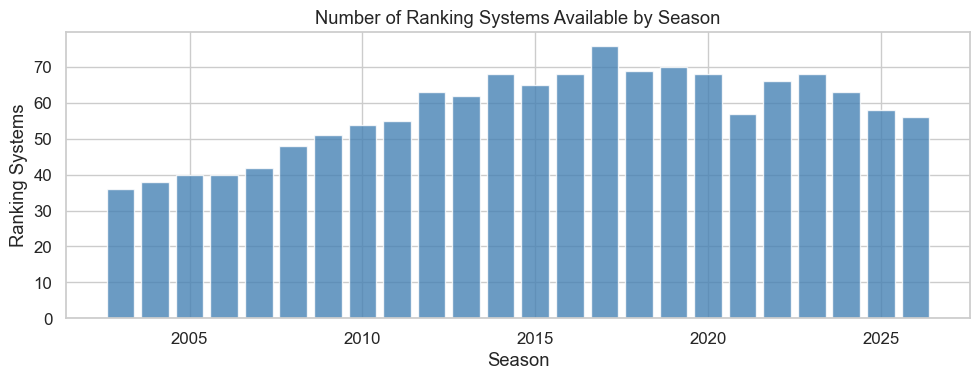

In [18]:
# Number of unique ranking systems
n_systems = massey["SystemName"].nunique()
print(f"Total unique ranking systems: {n_systems}")

# Systems per season
systems_per_season = massey.groupby("Season")["SystemName"].nunique()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(systems_per_season.index, systems_per_season.values, color="steelblue", alpha=0.8)
ax.set_title("Number of Ranking Systems Available by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Ranking Systems")
plt.tight_layout()
plt.show()

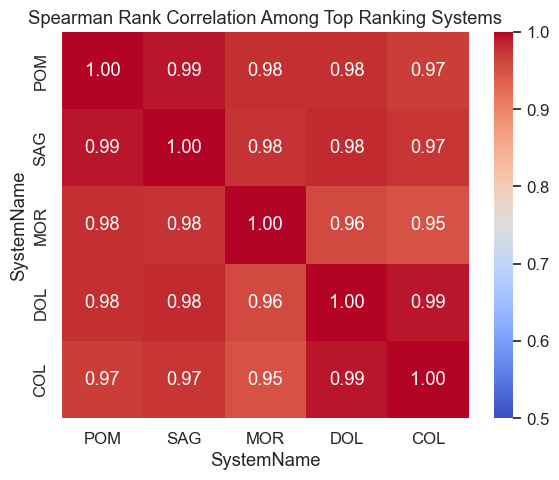

High correlations indicate strong agreement among these ranking systems.
This suggests they capture similar underlying team strength signals.


In [19]:
# Correlation among a few well-known systems at end of regular season (day 133)
# Filter to the last ranking day available per season per system
top_systems = ["POM", "SAG", "MOR", "DOL", "COL"]
available = massey[massey["SystemName"].isin(top_systems)].copy()

# Use latest ranking day per season
latest_day = available.groupby(["Season", "SystemName"])["RankingDayNum"].max().reset_index()
available = available.merge(latest_day, on=["Season", "SystemName", "RankingDayNum"])

# Pivot to get system ranks side by side
pivot = available.pivot_table(
    index=["Season", "TeamID"],
    columns="SystemName",
    values="OrdinalRank",
)

# Compute rank correlations
corr = pivot[top_systems].corr(method="spearman")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=0.5, vmax=1.0, ax=ax)
ax.set_title("Spearman Rank Correlation Among Top Ranking Systems")
plt.tight_layout()
plt.show()

print("High correlations indicate strong agreement among these ranking systems.")
print("This suggests they capture similar underlying team strength signals.")

---

## Key Takeaways

1. **Scoring**: Men's games have higher average scores than women's. Both show scoring trend changes over the decades.
2. **Home Court**: Strong home-court advantage in regular season for both genders, with the majority of wins occurring at the home venue.
3. **Seeds**: Lower-numbered seeds (1-4) dominate tournament wins. Upsets decrease as seed difference increases, but are never negligible.
4. **Champions**: Historically, 1-seeds win the championship most often, but seeds 2-3 and occasional Cinderellas break through.
5. **Conferences**: A small number of conferences (ACC, Big East/Ten/12, SEC) account for a disproportionate share of tournament success.
6. **Rankings**: Multiple computer ranking systems are available and highly correlated, providing robust features for modeling.

**Next steps**: Feature engineering (Notebook 02) will build on these observations to construct predictive features.